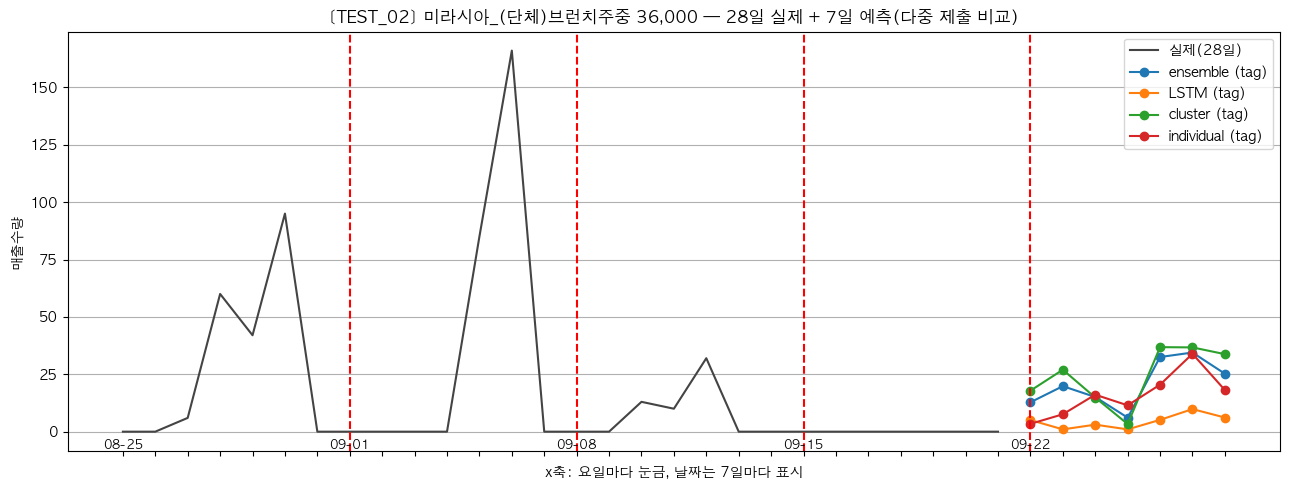

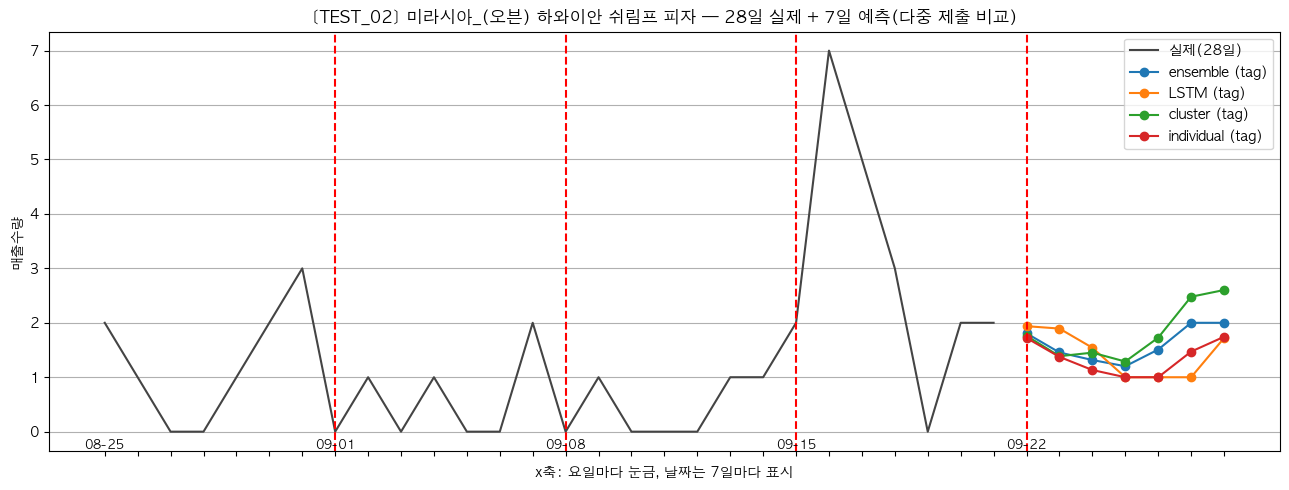

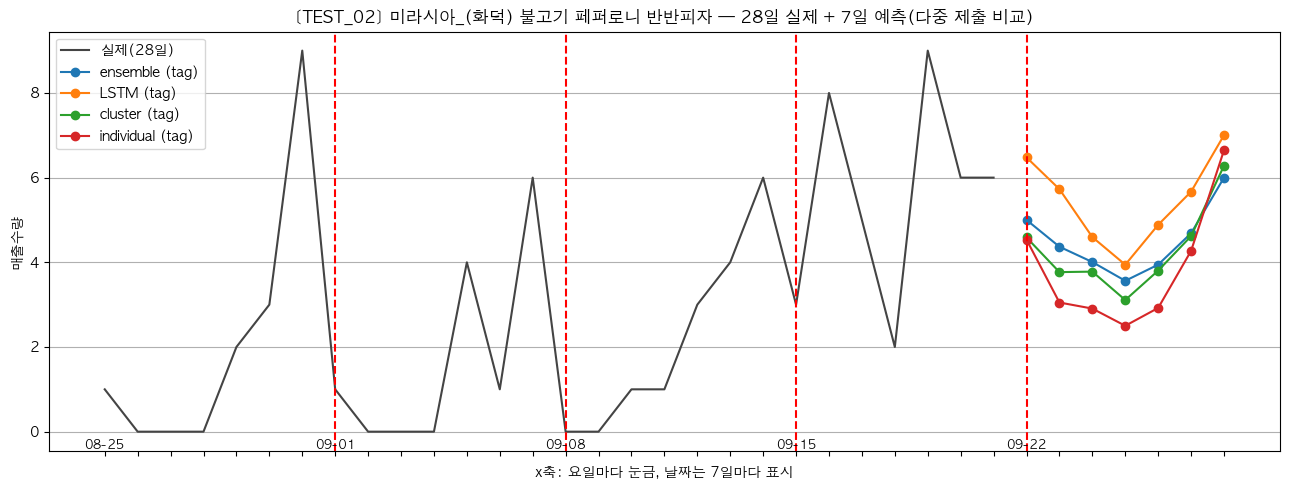

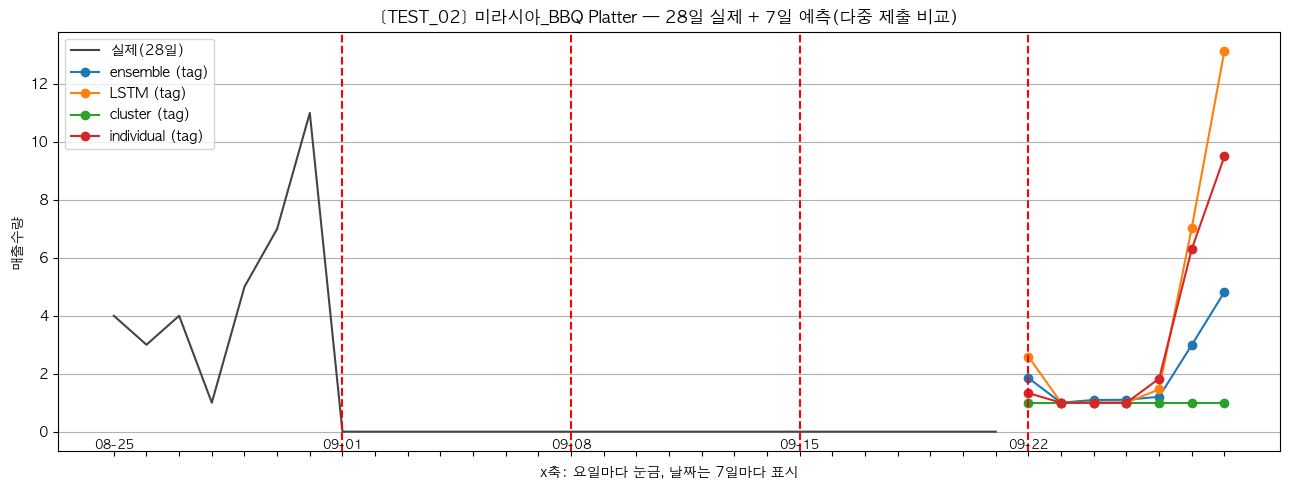

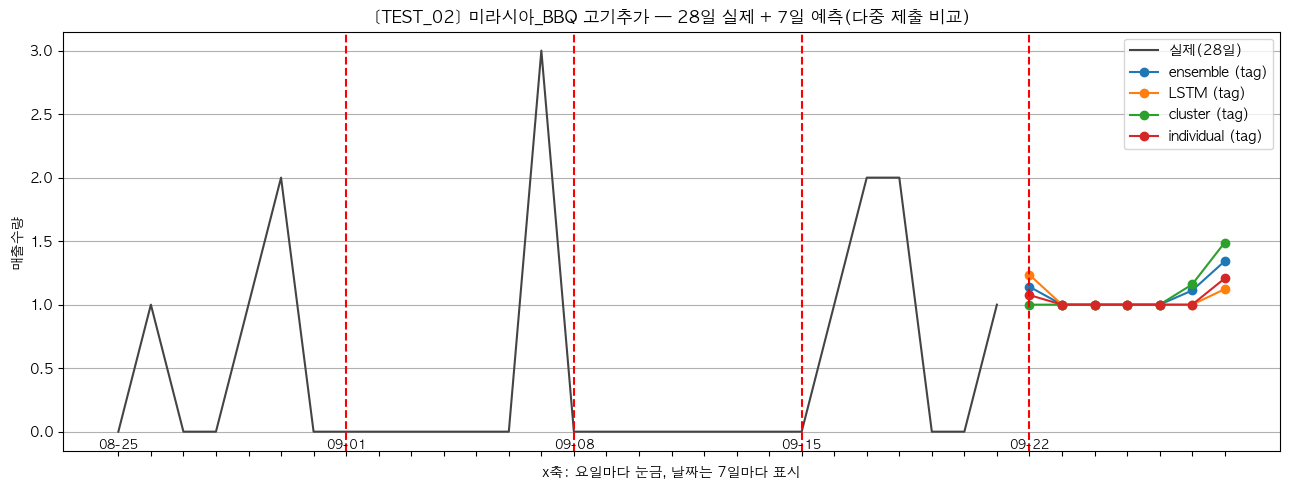

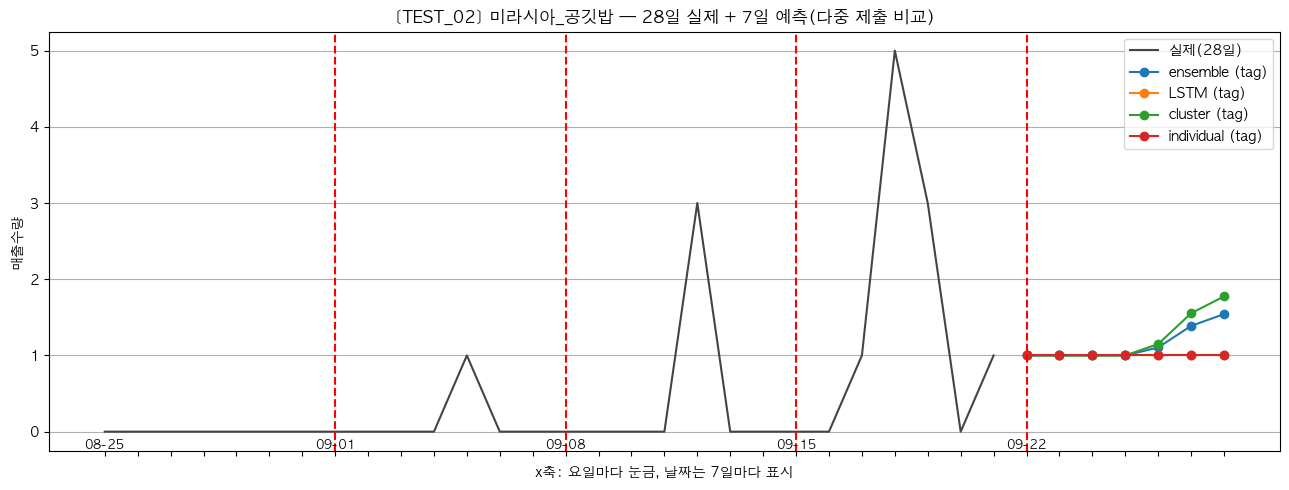

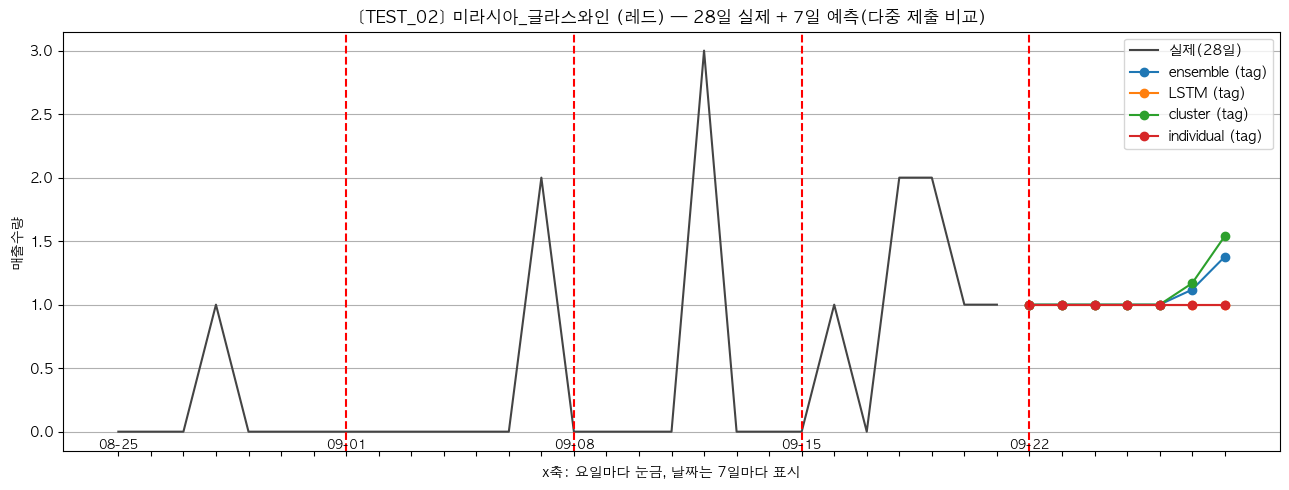

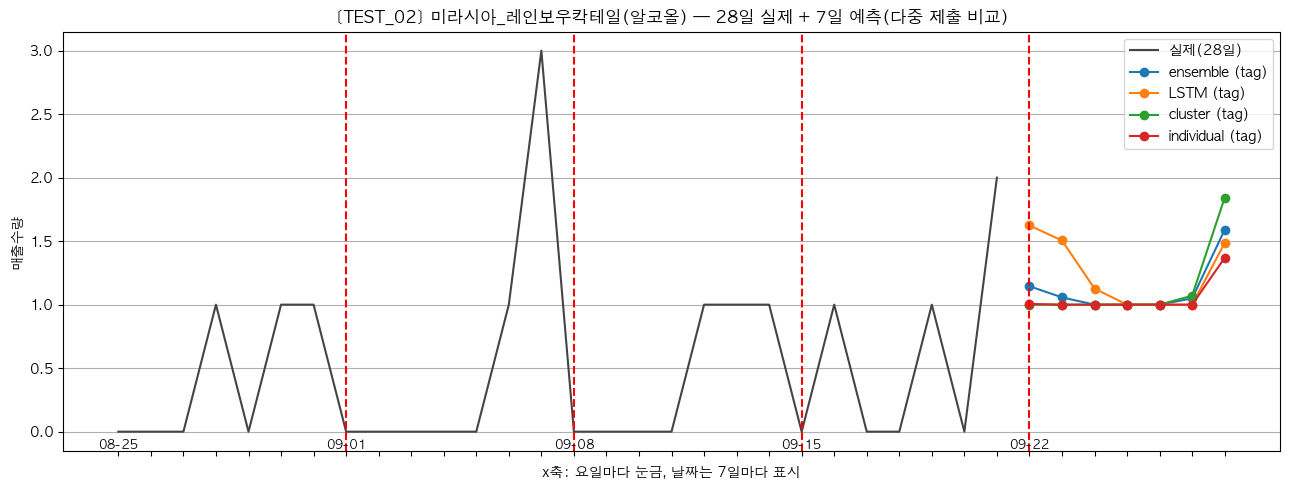

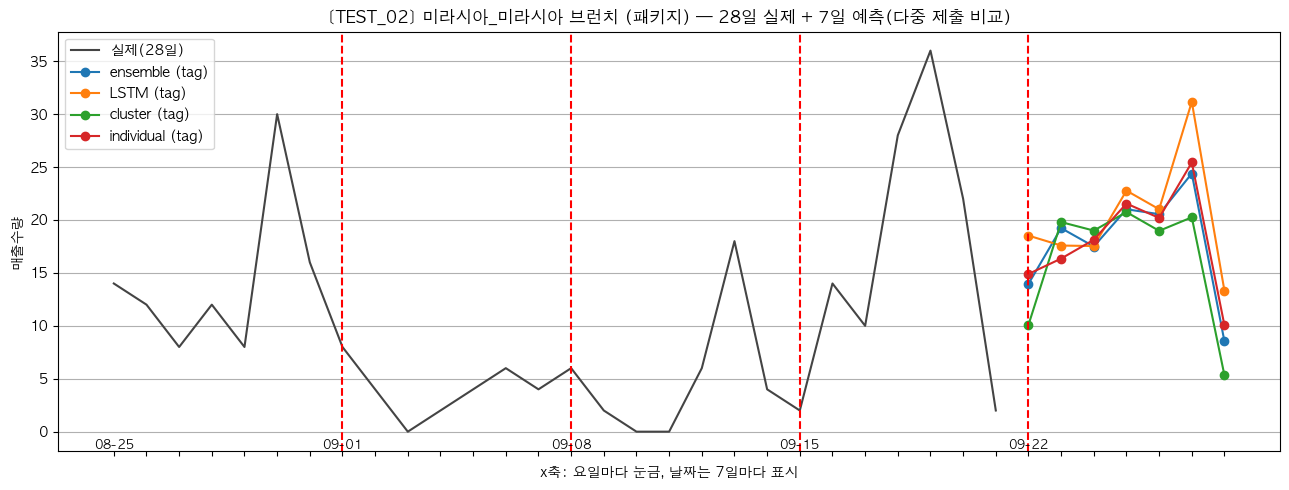

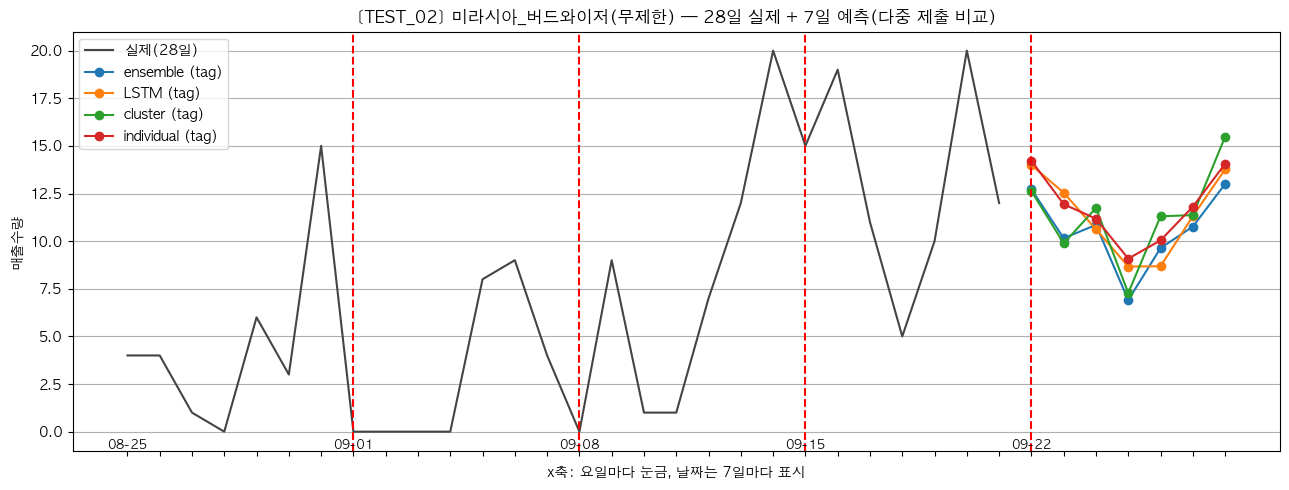

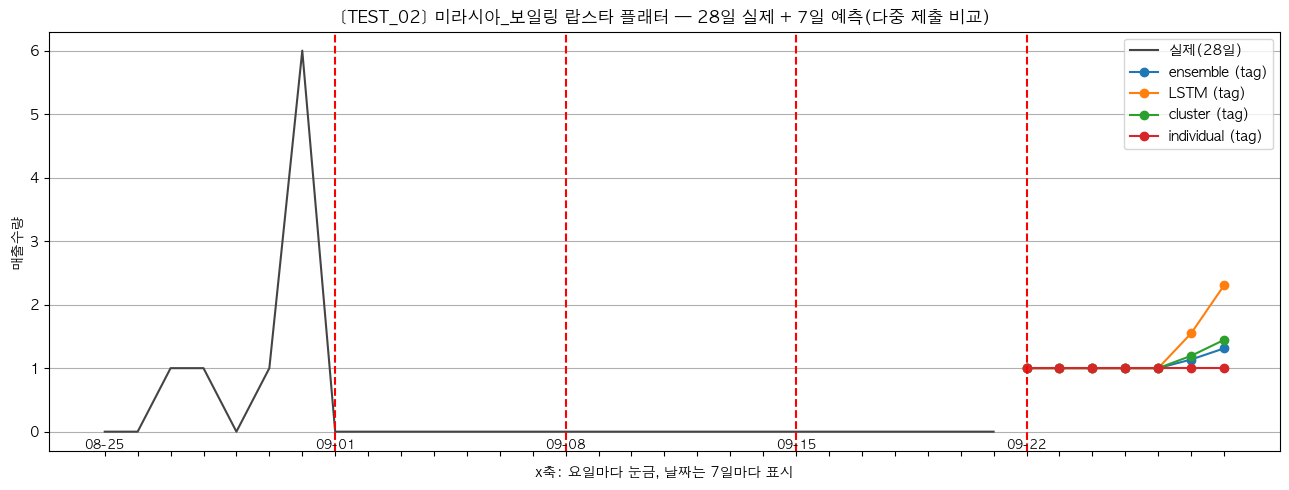

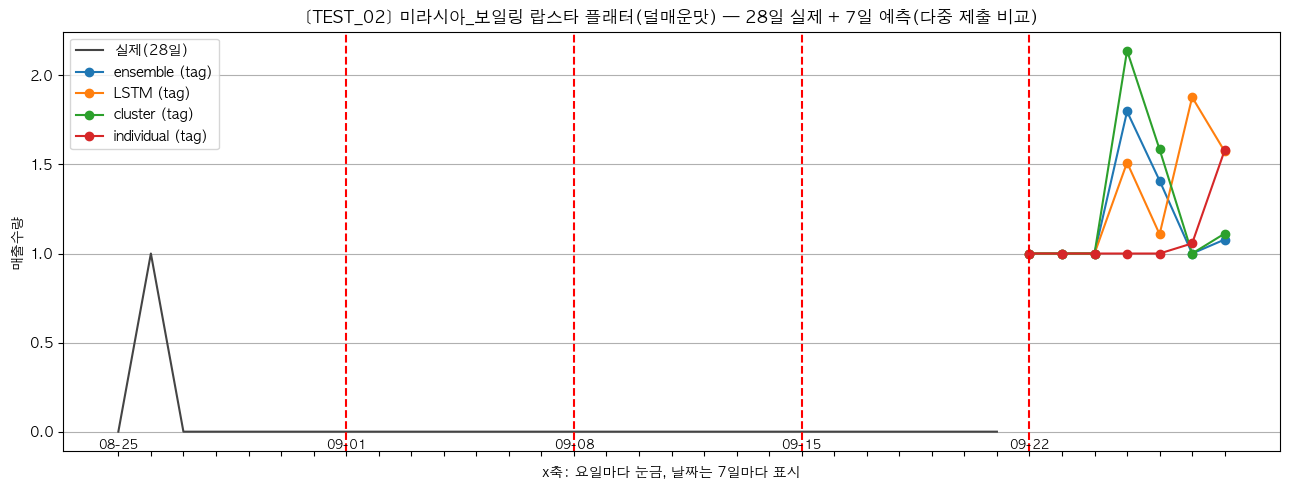

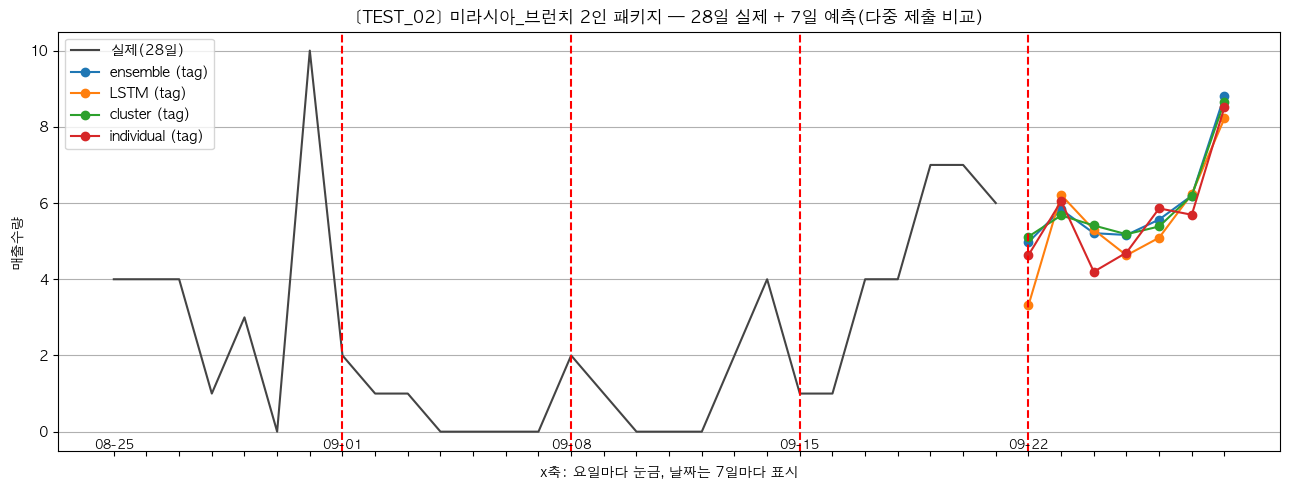

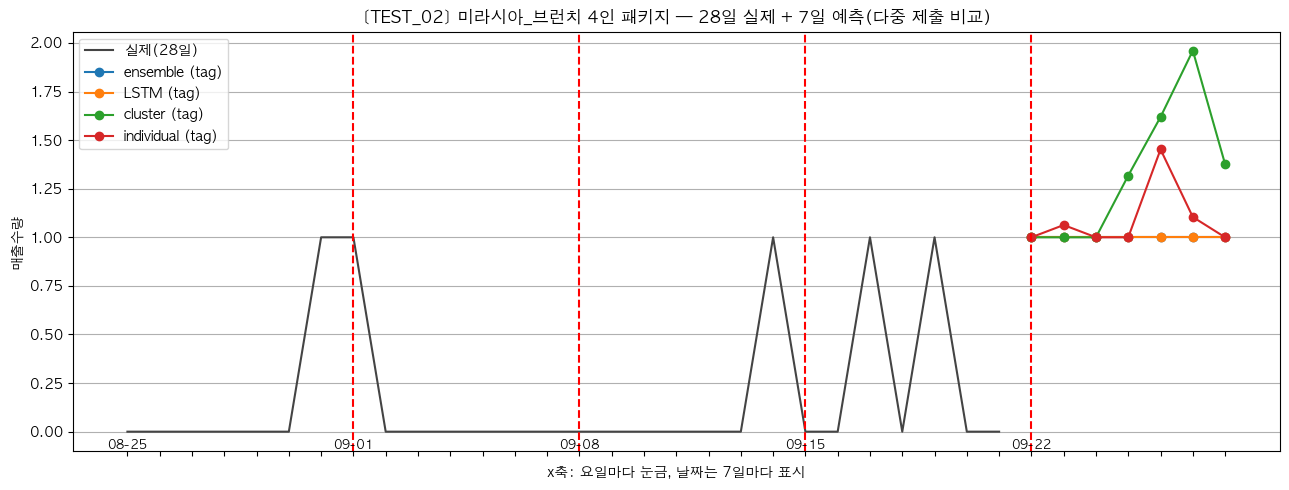

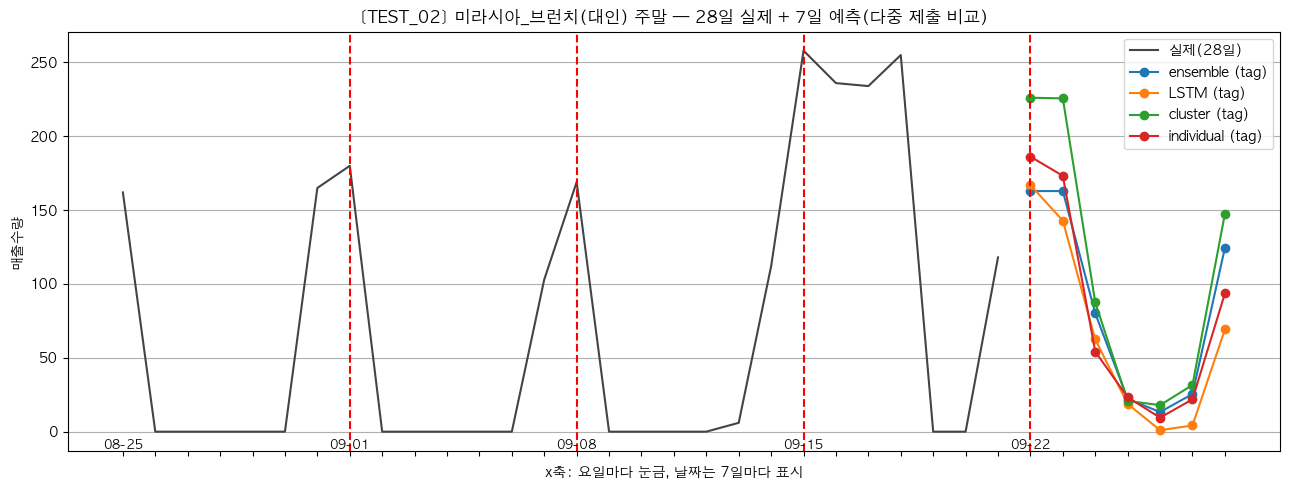

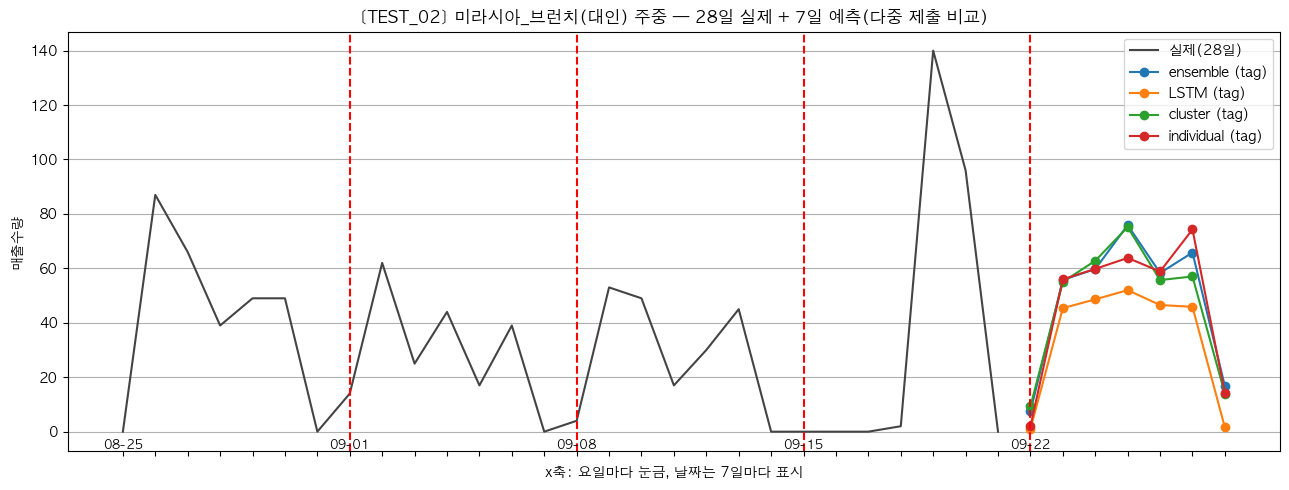

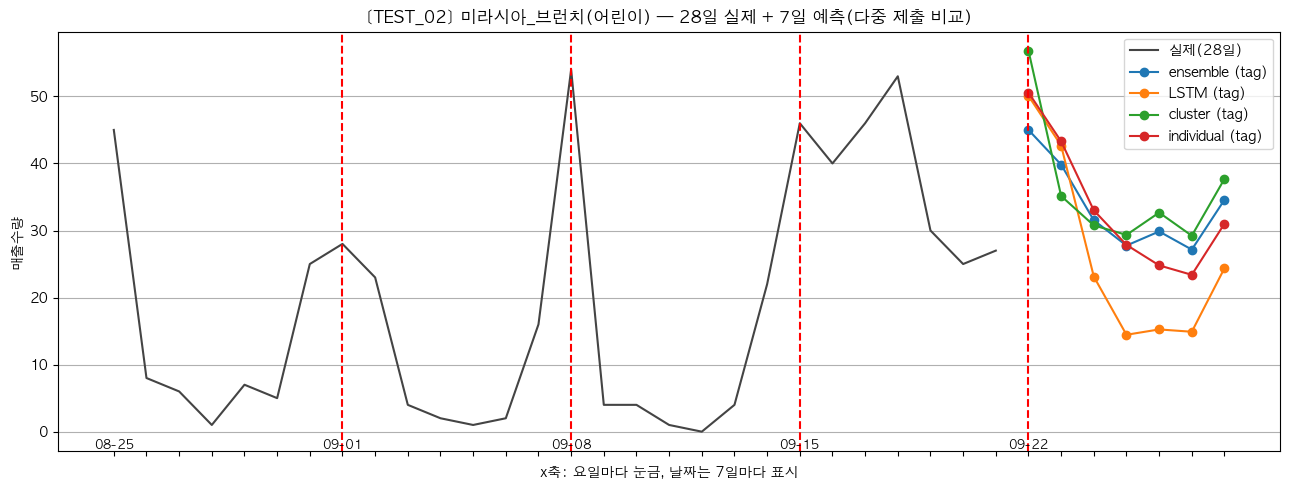

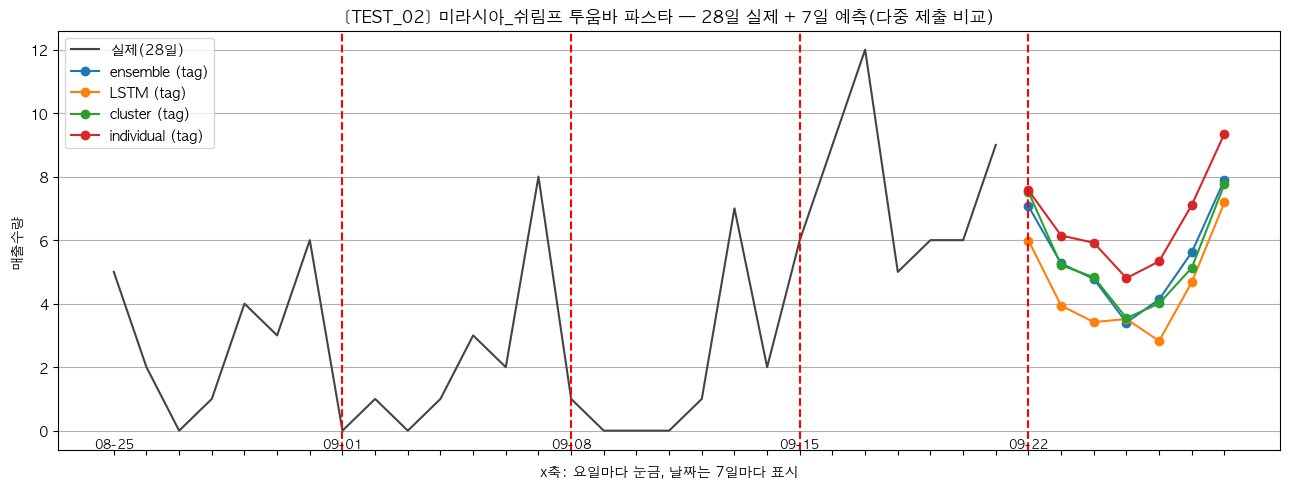

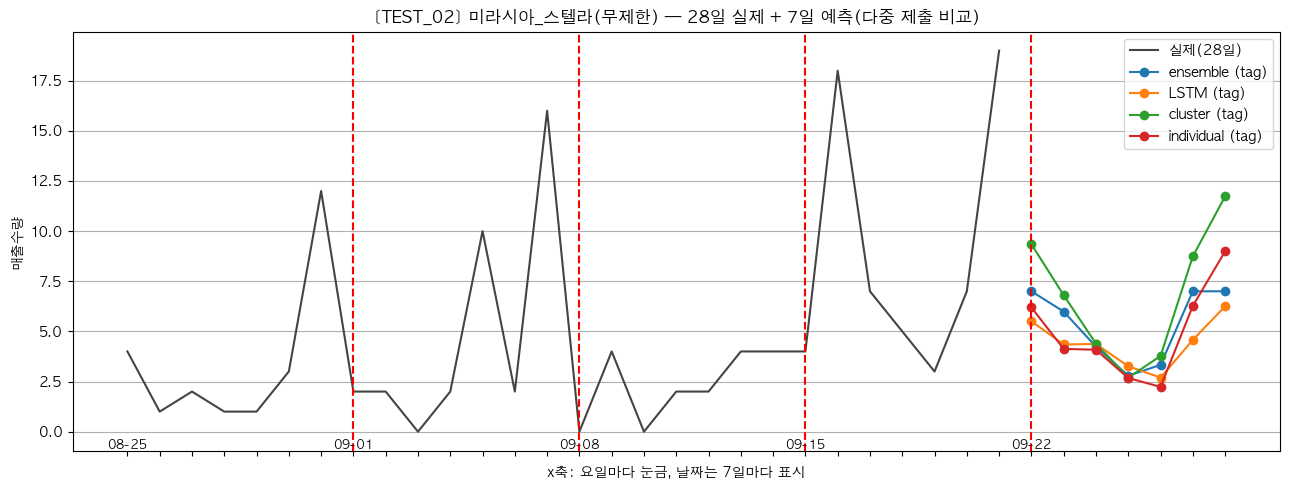

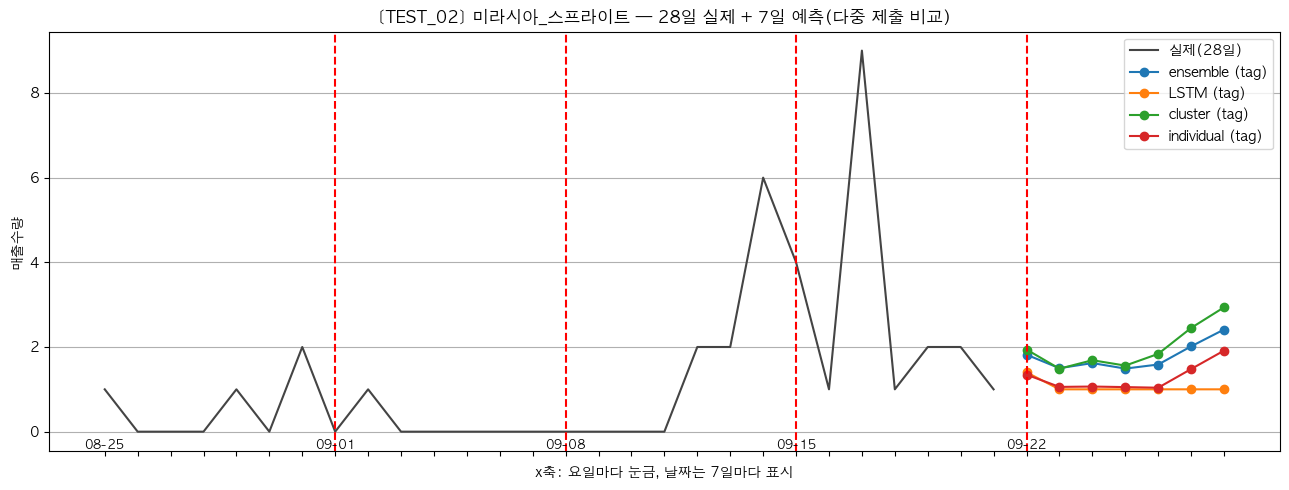

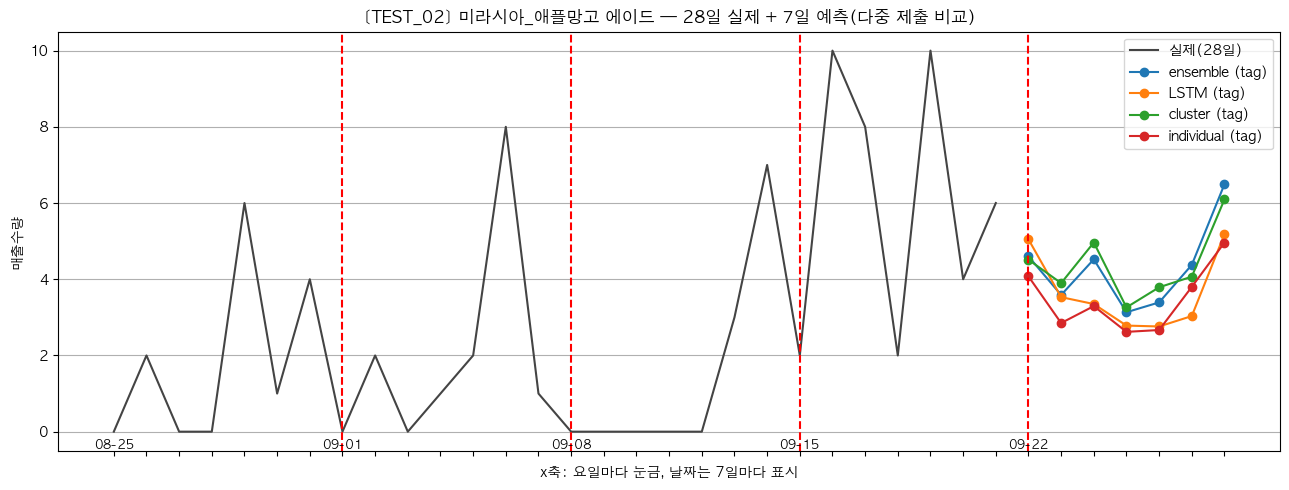

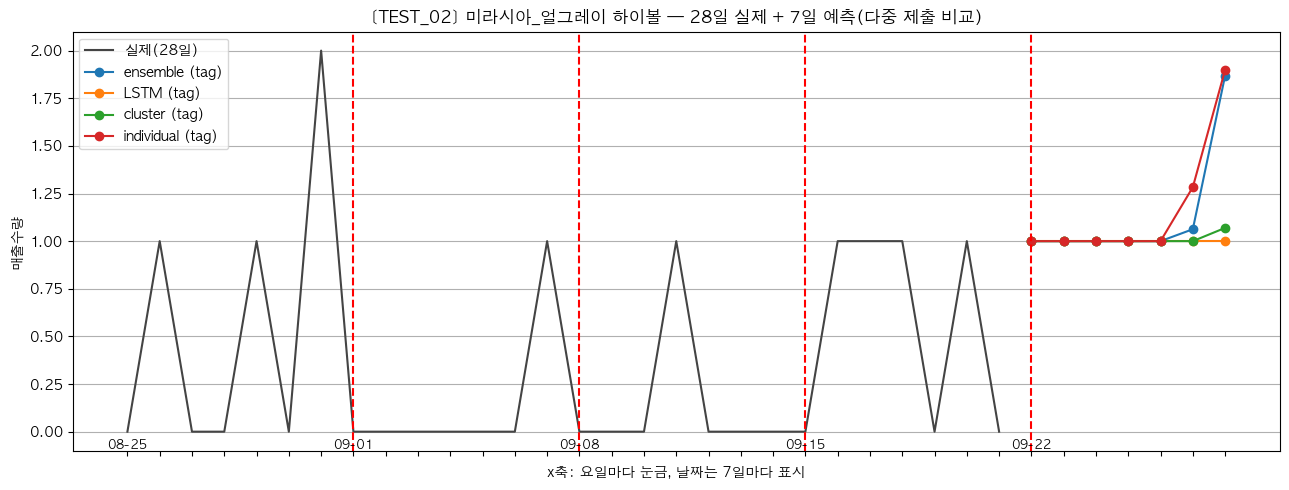

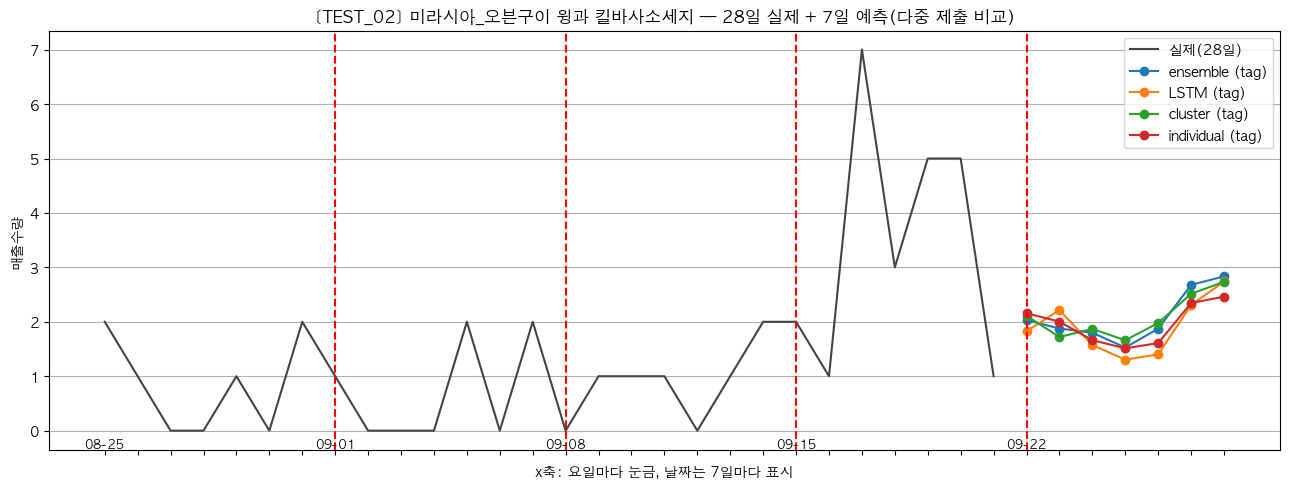

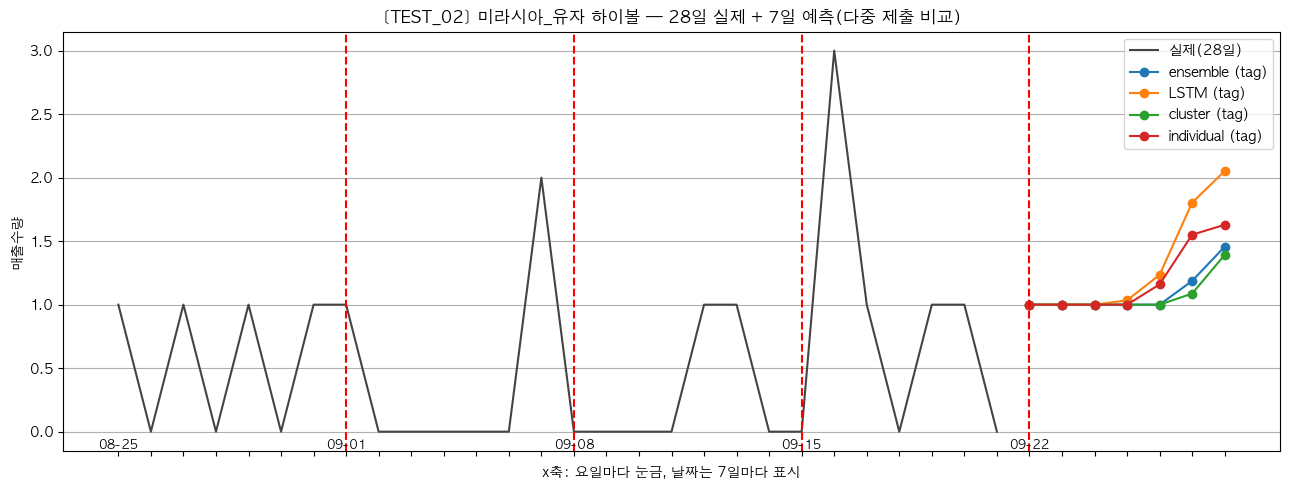

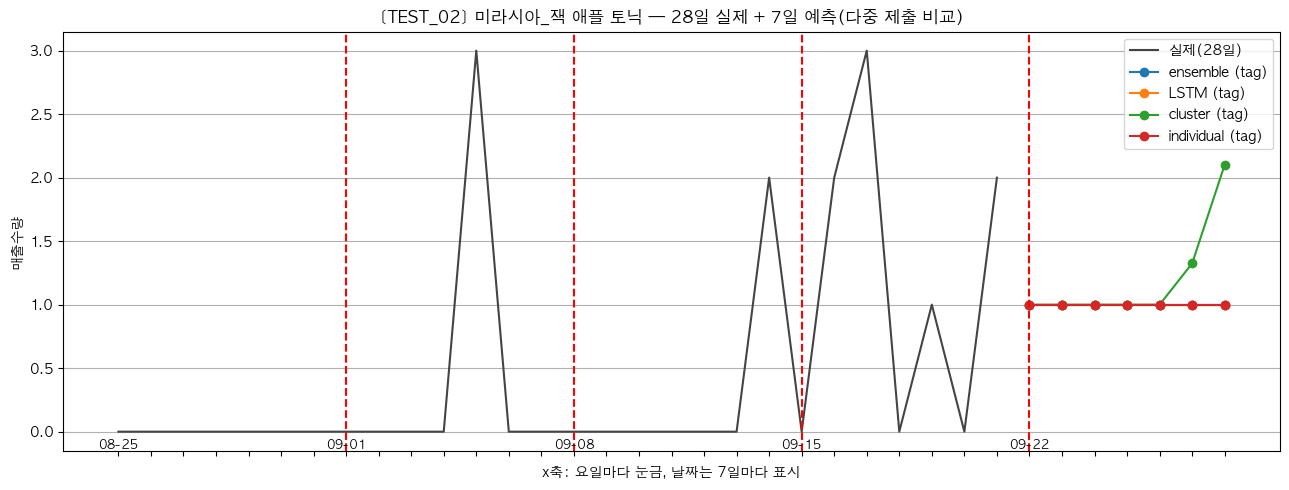

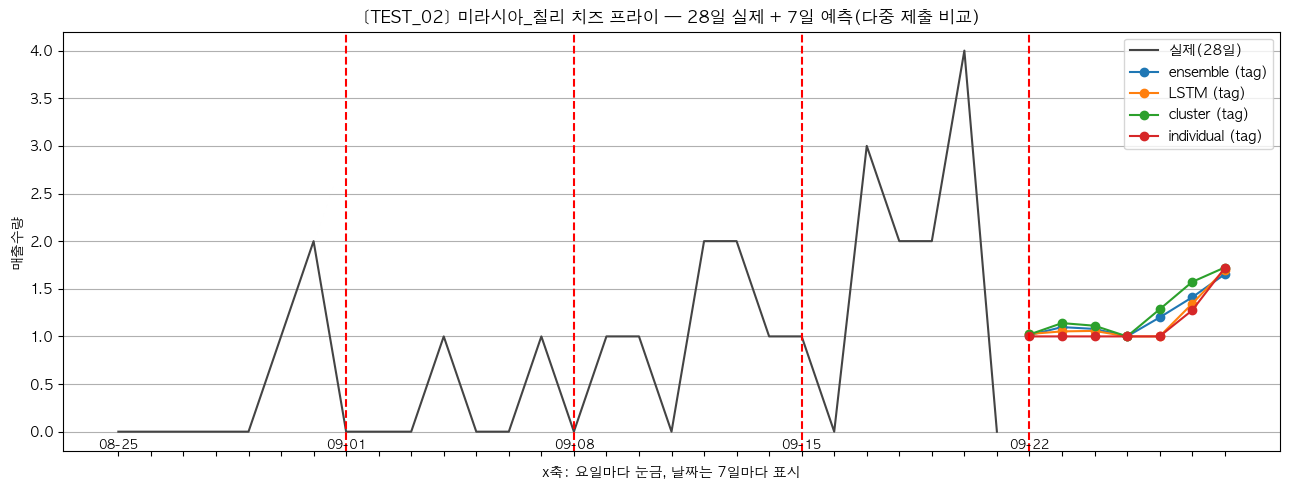

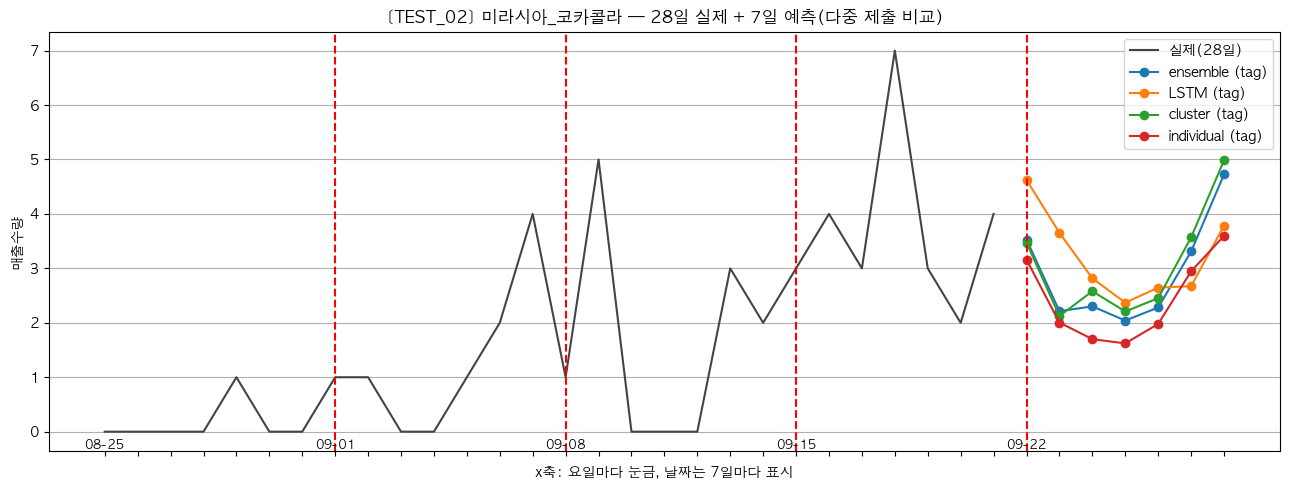

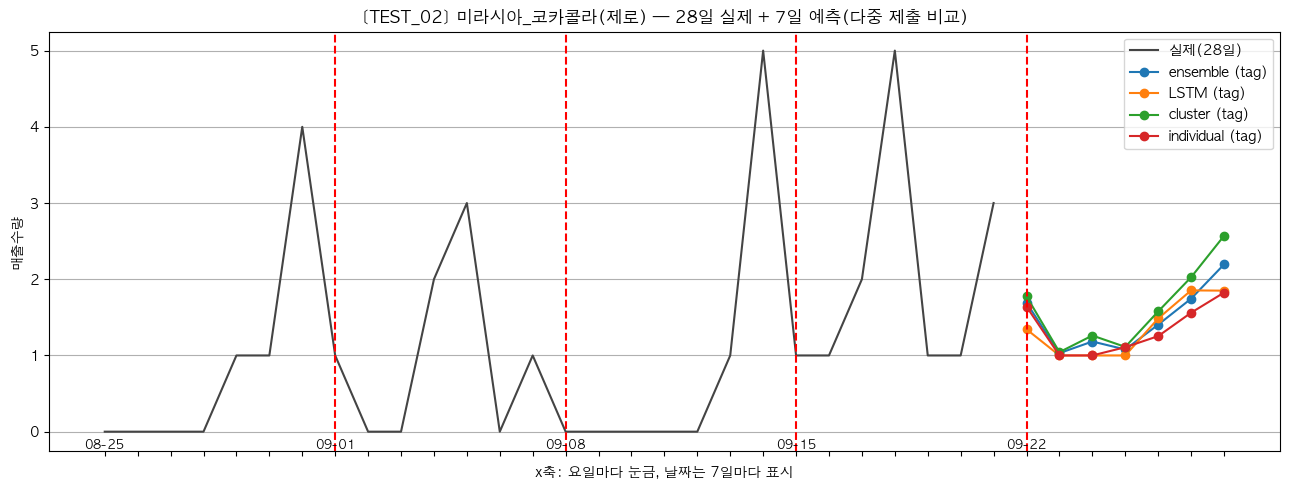

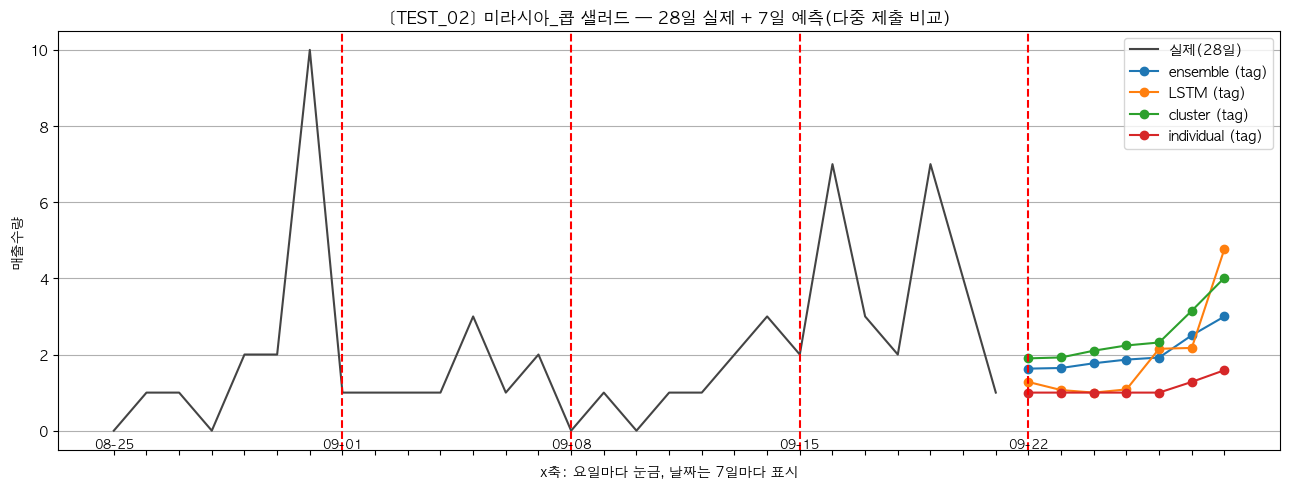

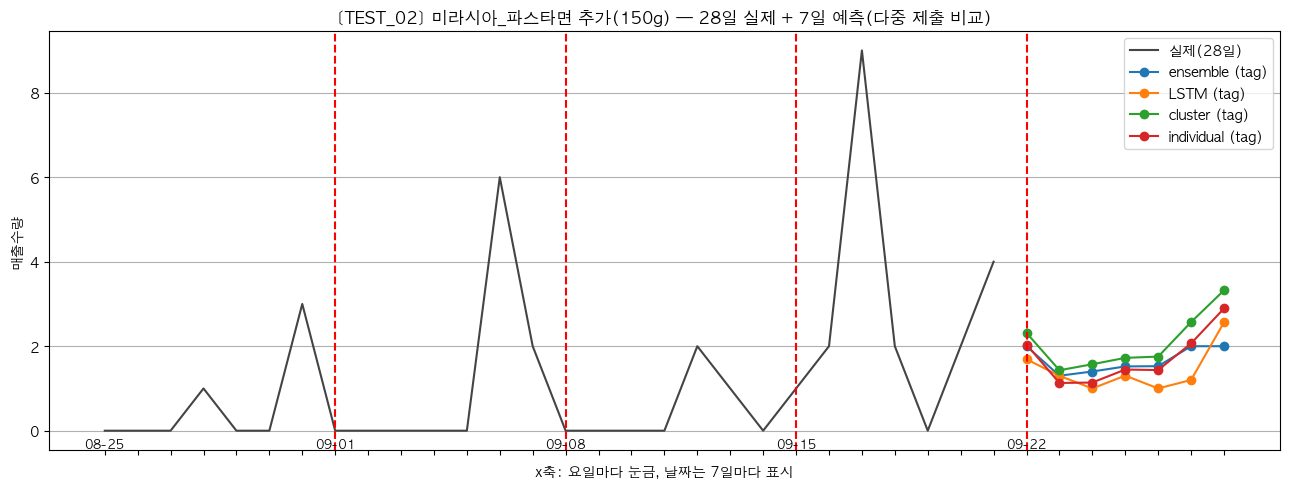

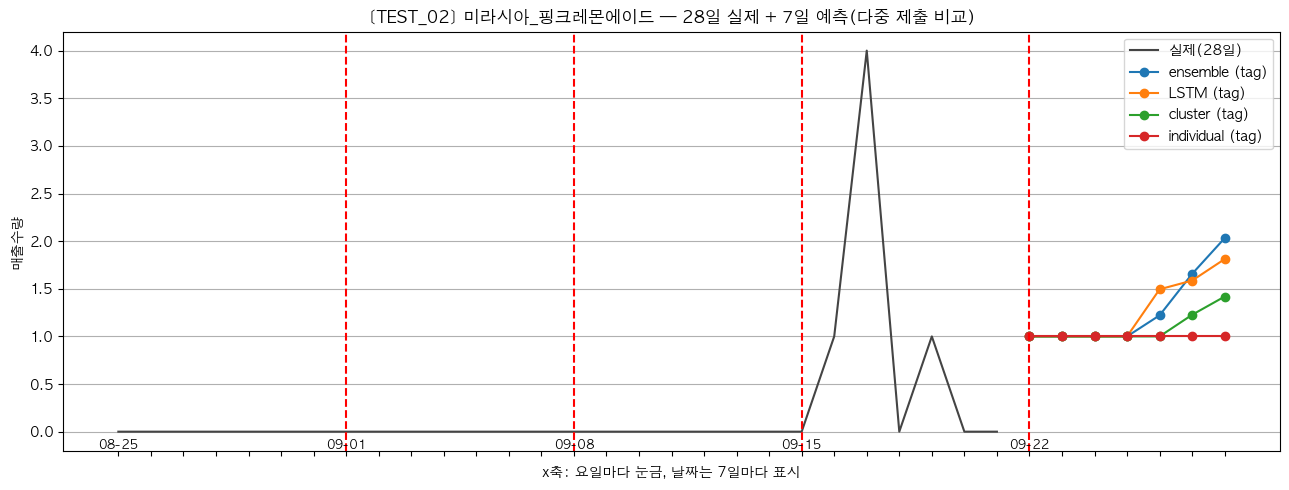

In [24]:
# ─────────────────────────────────────────────────────────────
# 다중 제출 비교 (자동 정규화 + 원인 진단 + 업장명 필터) — 조용 모드(선택)
# ─────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings("ignore")

# 3. 폰트 경로 확인 및 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'  # macOS

# ▼ 경로/선택값만 맞추세요
BASE_PATH    = "./"   # TEST_00.csv ~ TEST_09.csv 위치
TEST_ID      = "02"         # "00" ~ "09"
SHOP_FILTER  = "미라시아"           # ""=모든 업장, "로비라운지" 등 업장명 부분일치
MENU_FILTER  = ""           # ""=모든 메뉴, "아메리카노" 등 메뉴명 부분일치
DEBUG        = True         # 원인 진단 메시지 출력 여부

# ▼ 제출 파일 목록: (라벨, 경로) 튜플들을 여러 개 추가
SUBMISSIONS = [
    ("ensemble", "./Submission/ensemble_submission_p90.csv"),
    ("LSTM", "./Prediction/v8_01_nonuse_valid.csv"),
    ("cluster", "./submission_4_FIXED.csv"),
    ("individual", './ens_individual_0.csv')
]

# ───────────────── 공용 로더
def load_test_df(test_id: str) -> pd.DataFrame:
    path = os.path.join(BASE_PATH, f"TEST_{test_id}.csv")
    df = pd.read_csv(path)
    # 표준화
    df = df.rename(columns={c: c.strip() for c in df.columns})
    need = {"영업일자","영업장명_메뉴명","매출수량"}
    if not need.issubset(df.columns):
        raise ValueError("TEST 파일에는 '영업일자','영업장명_메뉴명','매출수량' 컬럼이 필요합니다.")
    df["영업일자"] = pd.to_datetime(df["영업일자"])
    df["영업장명_메뉴명"] = df["영업장명_메뉴명"].astype(str).str.strip()
    df["매출수량"] = pd.to_numeric(df["매출수량"], errors="coerce").fillna(0.0)
    return df.sort_values(["영업장명_메뉴명","영업일자"]).reset_index(drop=True)

def load_submission_df(path: str) -> pd.DataFrame:
    sub = pd.read_csv(path)
    sub = sub.rename(columns={c: c.strip() for c in sub.columns})
    # '영업일자' 대체 키워드도 가볍게 지원
    if "영업일자" not in sub.columns:
        for alt in ["date","Date","ds","일자","날짜"]:
            if alt in sub.columns:
                sub = sub.rename(columns={alt: "영업일자"})
                break
    return sub

# ───────────────── 제출 정규화: 어떤 포맷이든 long으로
def normalize_submission_to_long(sub_df: pd.DataFrame) -> pd.DataFrame:
    df = sub_df.copy()
    # 이미 long?
    if {"영업일자","영업장명_메뉴명","매출수량"}.issubset(df.columns):
        out = df[["영업일자","영업장명_메뉴명","매출수량"]].copy()
        out["영업장명_메뉴명"] = out["영업장명_메뉴명"].astype(str).str.strip()
        out["매출수량"] = pd.to_numeric(out["매출수량"], errors="coerce").fillna(0.0)
        return out

    # Wide → melt
    if "영업일자" in df.columns:
        menu_cols = [c for c in df.columns if c != "영업일자"]
        if len(menu_cols) == 0:
            raise ValueError("제출 파일이 Wide 형식처럼 보이지만 메뉴 열이 없습니다.")
        melted = df.melt(id_vars=["영업일자"], value_vars=menu_cols,
                         var_name="영업장명_메뉴명", value_name="매출수량")
        melted["영업장명_메뉴명"] = melted["영업장명_메뉴명"].astype(str).str.strip()
        melted["매출수량"] = pd.to_numeric(melted["매출수량"], errors="coerce").fillna(0.0)
        return melted[["영업일자","영업장명_메뉴명","매출수량"]]

    raise ValueError("제출 파일 포맷을 인식하지 못했습니다. "
                     "Wide면 '영업일자'가 있어야 하고, Long이면 "
                     "['영업일자','영업장명_메뉴명','매출수량']이 있어야 합니다.")

# ───────────────── 7일 추출 (정규화된 long 입력)
def extract_next7_from_long(sub_long: pd.DataFrame, test_id: str,
                            menu_name: str, last_test_date: pd.Timestamp):
    sl = sub_long.copy()
    sl["영업장명_메뉴명"] = sl["영업장명_메뉴명"].astype(str).str.strip()

    # 1) TEST태그 방식
    mask_tag = sl["영업일자"].astype(str).str.startswith(f"TEST_{test_id}+")
    if mask_tag.any():
        t = sl[mask_tag & (sl["영업장명_메뉴명"] == menu_name)].copy()
        if not t.empty:
            t["_k"] = t["영업일자"].astype(str).str.extract(r"\+(\d+)").astype(int)
            t = t.sort_values("_k")
            vals = t["매출수량"].to_numpy()
            if len(vals) >= 7:
                return vals[:7], "tag"
    # 2) 실제 날짜 방식
    sl["_parsed_date"] = pd.to_datetime(sl["영업일자"], errors="coerce")
    desired = [last_test_date + pd.Timedelta(days=i) for i in range(1, 8)]
    t = sl[(sl["영업장명_메뉴명"] == menu_name) & (sl["_parsed_date"].isin(desired))].copy()
    if not t.empty:
        t = t.sort_values("_parsed_date")
        vals = t["매출수량"].to_numpy()
        if len(vals) >= 7:
            return vals[:7], "date"

    return None, "none"

# ───────────────── 유틸
def build_actual_28(test_df: pd.DataFrame, menu_name: str) -> pd.DataFrame:
    actual = test_df[test_df["영업장명_메뉴명"] == menu_name].copy()
    daily  = (actual.groupby("영업일자", as_index=False)["매출수량"]
                    .sum().sort_values("영업일자"))
    return daily

def get_shop(name: str) -> str:
    """'영업장명_메뉴명'에서 업장명만 추출(첫 '_' 이전). '_'가 없으면 전체를 업장명으로 간주."""
    name = str(name)
    if "_" in name:
        return name.split("_", 1)[0].strip()
    return name.strip()

# ───────────────── 플롯: 28일 실제 + 다중 제출 7일 오버레이
def plot_menu_multi(daily_actual: pd.DataFrame,
                    preds_dict: dict,   # label -> (yhat7, mode) or (None, reason)
                    test_id: str, menu_name: str):
    last_d = daily_actual["영업일자"].max()
    pred_dates = [last_d + pd.Timedelta(days=i) for i in range(1, 8)]
    df_all = pd.concat([
        daily_actual.assign(구분="실제"),
        pd.DataFrame({"영업일자": pred_dates, "매출수량": np.nan, "구분": "예측"}),
    ], ignore_index=True).sort_values("영업일자").reset_index(drop=True)

    n = len(df_all)
    x_idx = np.arange(n)
    start_pred = len(daily_actual)
    x_pred = np.arange(start_pred, n)

    plt.figure(figsize=(13,5))

    # 실제 28일: 기준선 (진회색)
    plt.plot(np.arange(len(daily_actual)),
             daily_actual["매출수량"].to_numpy(),
             "-", color="#444444", linewidth=1.5, label="실제(28일)")

    # 각 제출 7일: 색 자동 사이클
    any_drawn = False
    for label, pack in preds_dict.items():
        yhat7, mode_or_reason = pack
        if yhat7 is None:
            continue
        plt.plot(x_pred, yhat7, "-o", label=f"{label} ({mode_or_reason})")
        any_drawn = True

    if not any_drawn:
        plt.close()
        return

    # x축: 요일마다 눈금만, 라벨은 공백
    plt.xticks(ticks=x_idx, labels=[""]*n)

    # 7일마다 날짜(mm-dd)만 하단에 표시
    ymin, _ = plt.ylim()
    for k in range(0, n, 7):
        date_str = df_all["영업일자"].iloc[k].strftime("%m-%d")
        plt.text(k, ymin, date_str, ha="center", va="bottom", fontsize=9, color="black")

    # 7일마다 동일 굵기의 빨간 구분선
    for k in range(0, n+1, 7):
        if 0 < k < n:
            plt.axvline(x=k, color="red", linestyle="--", linewidth=1.5)

    plt.title(f"[TEST_{test_id}] {menu_name} — 28일 실제 + 7일 예측(다중 제출 비교)")
    plt.xlabel("x축: 요일마다 눈금, 날짜는 7일마다 표시")
    plt.ylabel("매출수량")
    plt.grid(True, axis="y")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ───────────────── 실행
try:
    test_df = load_test_df(TEST_ID)
    # 메뉴 리스트
    menus = sorted(test_df["영업장명_메뉴명"].astype(str).str.strip().unique())

    # ① 업장명 필터 (부분일치): 업장명만 추출하여 필터링
    if SHOP_FILTER:
        menus = [m for m in menus if SHOP_FILTER.lower() in get_shop(m).lower()]
        if not menus and DEBUG:
            print(f"[INFO] 업장명 필터 결과가 비었습니다: SHOP_FILTER='{SHOP_FILTER}'")

    # ② 메뉴명 필터 (부분일치)
    if MENU_FILTER:
        menus = [m for m in menus if MENU_FILTER.lower() in m.lower()]
        if not menus and DEBUG:
            print(f"[INFO] 메뉴명 필터 결과가 비었습니다: MENU_FILTER='{MENU_FILTER}'")

    if not menus:
        raise ValueError("선택된 필터 조합에 해당하는 메뉴가 없습니다.")

    # 제출들 로드+정규화 (없으면 None)
    normalized_subs = []
    for label, path in SUBMISSIONS:
        if not os.path.exists(path):
            if DEBUG: print(f"[WARN] 파일 없음: {label} -> {path}")
            normalized_subs.append((label, None))
            continue
        try:
            sdf = load_submission_df(path)
            sdf_long = normalize_submission_to_long(sdf)
            sdf_long["영업장명_메뉴명"] = sdf_long["영업장명_메뉴명"].astype(str).str.strip()
            normalized_subs.append((label, sdf_long))
        except Exception as e:
            if DEBUG: print(f"[ERR] 정규화 실패: {label} -> {e}")
            normalized_subs.append((label, None))

    # 메뉴별로 그림 + 진단
    for m in menus:
        try:
            daily = build_actual_28(test_df, m)
            last_d = daily["영업일자"].max()

            preds = {}
            for label, s_long in normalized_subs:
                if s_long is None:
                    preds[label] = (None, "load_fail")
                    continue
                y7, how = extract_next7_from_long(s_long, TEST_ID, m, last_d)
                if y7 is None:
                    # 진단 힌트
                    has_tag = s_long["영업일자"].astype(str).str.startswith(f"TEST_{TEST_ID}+").any()
                    desired = [last_d + pd.Timedelta(days=i) for i in range(1, 8)]
                    has_dates = pd.to_datetime(s_long["영업일자"], errors="coerce").isin(desired).any()
                    if DEBUG:
                        if not has_tag and not has_dates:
                            print(f"[MISS] {label} / 업장[{get_shop(m)}] 메뉴[{m}] → TEST태그/날짜 둘 다 매칭 안됨")
                        elif has_tag and not has_dates:
                            print(f"[MISS] {label} / 업장[{get_shop(m)}] 메뉴[{m}] → TEST태그는 있으나 메뉴명 불일치 가능")
                        elif not has_tag and has_dates:
                            print(f"[MISS] {label} / 업장[{get_shop(m)}] 메뉴[{m}] → 날짜는 있으나 메뉴명 불일치 가능")
                        else:
                            print(f"[MISS] {label} / 업장[{get_shop(m)}] 메뉴[{m}] → 7개 미만/중복/결측 이슈")
                    preds[label] = (None, "no_match")
                else:
                    preds[label] = (y7, how)

            # 하나라도 그릴 예측이 있으면 출력
            if any((v[0] is not None and len(v[0])==7) for v in preds.values()):
                plot_menu_multi(daily, preds, TEST_ID, m)
        except Exception as e:
            if DEBUG:
                print(f"[SKIP] 메뉴[{m}] 처리 중 오류: {e}")
            continue
except Exception as e:
    print(f"⚠️ {e}")
